In [1]:
import sys
from pathlib import Path
import torch
import numpy as np

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, EGEMAPS_DROPOUT, RANDOM_SEEDS
from model import AD_EGE_Model
from dataset import FeatureDataset, create_dataloaders
from train_DANN_ST_egemaps import train_st_dann_parallel_egemaps, validate_st_egemaps
from visualization import plot_training_curves, plot_dataset_comparison

In [ ]:
SOURCE_DATASET = "Pitt"
TARGET_DATASET = "Lu"

# Model Selection Weights
SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

# Accuracy Thresholds
MIN_SOURCE_ACC = 0  # Minimum required source domain validation accuracy
MIN_TARGET_ACC = 0  # Minimum required target domain validation accuracy

# Training Hyperparameters
WARMUP_EPOCHS = 30              # Warmup phase epochs (DANN on source only)
MAX_ITERATIONS = 10              # Maximum ST iterations
MAX_EPOCHS_PER_ITER = 60        # Max epochs per ST iteration
CONFIDENCE_THRESHOLD = 0.8      # Pseudo-label confidence threshold
MIN_PSEUDO_SAMPLES = 0          # Minimum pseudo-labeled samples required

# DANN Hyperparameters
DOMAIN_WARMUP_EPOCHS = 0       # Domain loss warmup epochs (lambda=0)
DOMAIN_ANNEAL_RATIO = 0      # Proportion of epochs for annealing
LAMBDA_CLASS = 1.0              # Classification loss weight
LAMBDA_DOMAIN = 1             # Domain adversarial loss weight

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Device: {device}")

Device: mps


In [3]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-egemaps-train.csv"
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-egemaps-val.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-egemaps-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-egemaps-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"ST_DANN_parallel_{SOURCE_DATASET}_to_{TARGET_DATASET}_egemaps_t{int(CONFIDENCE_THRESHOLD*100)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output: {MODEL_OUTPUT_DIR}")

Output: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_DANN_parallel_Pitt_to_Lu_egemaps_t70


In [4]:
# Load datasets
source_train_dataset = FeatureDataset(SOURCE_TRAIN_CSV, xlsr=False)
target_train_dataset = FeatureDataset(TARGET_TRAIN_CSV, xlsr=False)

source_val_loader = create_dataloaders(SOURCE_VAL_CSV, xlsr=False)
target_val_loader = create_dataloaders(TARGET_VAL_CSV, xlsr=False)

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 111 samples
Control: 49, Dementia: 62


Loading completed: 16 samples
Control: 8, Dementia: 8




In [5]:
def evaluate_and_visualize(seed, all_metrics, all_histories, all_pseudo_stats,
                           source_val_loader, target_val_loader, output_dir, device):
    """Evaluate best ST+DANN iteration and visualize results"""
    if not all_metrics:
        raise ValueError('all_metrics is empty; run training first.')
    
    # Find best iteration by avg_val_acc
    best_iter_idx = max(
        range(len(all_metrics)),
        key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0
    )
    best_metric = all_metrics[best_iter_idx]
    
    print('='*60)
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"Best Iteration: {best_iter_idx}")
    if best_metric:
        print(f"Best Avg Acc: {best_metric.get('avg_val_acc', 0)*100:.2f}%")
        print(f"  Source: {best_metric.get('source_val_acc', 0)*100:.2f}%")
        print(f"  Target: {best_metric.get('target_val_acc', 0)*100:.2f}%")
    print('='*60)
    
    model_path = output_dir / f"seed_{seed}" / f"st_iter_{best_iter_idx}.pth"
    print(f"Loading model from: {model_path}")
    
    best_model = AD_EGE_Model(dim_input=25, dim_hidden=32, dropout=EGEMAPS_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))
    
    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate_st_egemaps(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate_st_egemaps(
        best_model, target_val_loader, device
    )
    
    print(f"\n{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print('-'*85)
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print('-'*85)
    
    # Visualize
    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'ST+DANN Parallel (Seed {seed}, Iter {best_iter_idx})',
        custom_colors={
            f'{SOURCE_DATASET} (source)': '#3498db',
            f'{TARGET_DATASET} (target)': '#e74c3c'
        }
    )
    
    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics

In [6]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'pseudo_stats': [],
    'source_metrics': [],
    'target_metrics': []
}

## Seed 21

In [7]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel_egemaps(
    seed=21,
    source_train_dataset=source_train_dataset,  
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training on source only (30 epochs)

PHASE 1: DANN Training (Seed 21)


Epoch   1 | Train: 0.520 | Source Val: 0.550 | Target Val: 0.500 | Avg: 0.525 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5248)


Epoch   2 | Train: 0.557 | Source Val: 0.541 | Target Val: 0.500 | Avg: 0.520 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.575 | Source Val: 0.514 | Target Val: 0.562 | Avg: 0.538 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5380)


Epoch   4 | Train: 0.582 | Source Val: 0.559 | Target Val: 0.625 | Avg: 0.592 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5918)


...

Epoch   9 | Train: 0.611 | Source Val: 0.541 | Target Val: 0.562 | Avg: 0.552


Epoch  10 | Train: 0.604 | Source Val: 0.532 | Target Val: 0.500 | Avg: 0.516


Epoch  11 | Train: 0.582 | Source Val: 0.505 | Target Val: 0.625 | Avg: 0.565


Epoch  12 | Train: 0.591 | Source Val: 0.505 | Target Val: 0.312 | Avg: 0.409
Early stopping at epoch 12
Iteration 1 completed: Avg 56.50% | Source 56.76% | Target 56.25%

ST Iteration 2



Pseudo-label Generation (threshold=0.70):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Only 0 pseudo-samples (< 2), stopping ST

Phase 2 completed. Best iteration: 1, Avg 56.50%


Training Completed (Seed 21)



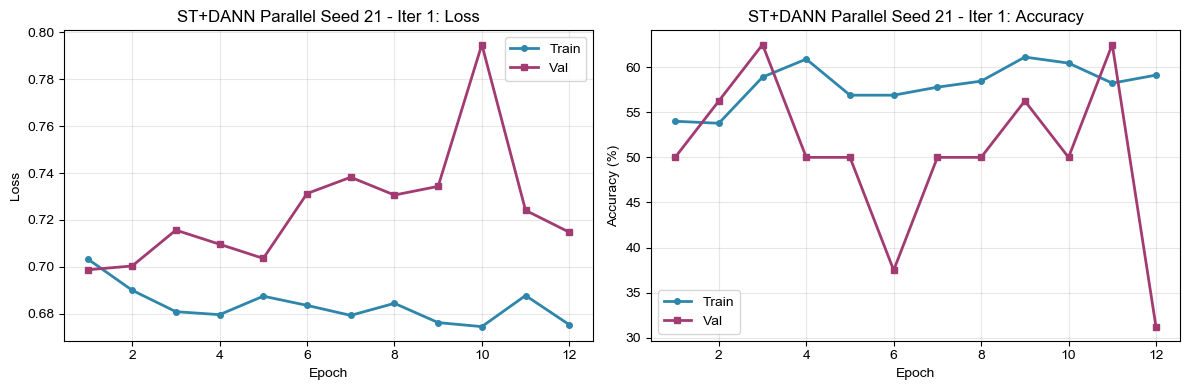

Evaluating Best Model (Seed 21)
Best Iteration: 1
Best Avg Acc: 56.50%
  Source: 56.76%
  Target: 56.25%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_DANN_parallel_Pitt_to_Lu_egemaps_t70/seed_21/st_iter_1.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           56.76%      0.7037       91.94%       12.24%    0.6834
Lu (target domain)             56.25%      0.6957      100.00%       12.50%    0.7003
-------------------------------------------------------------------------------------


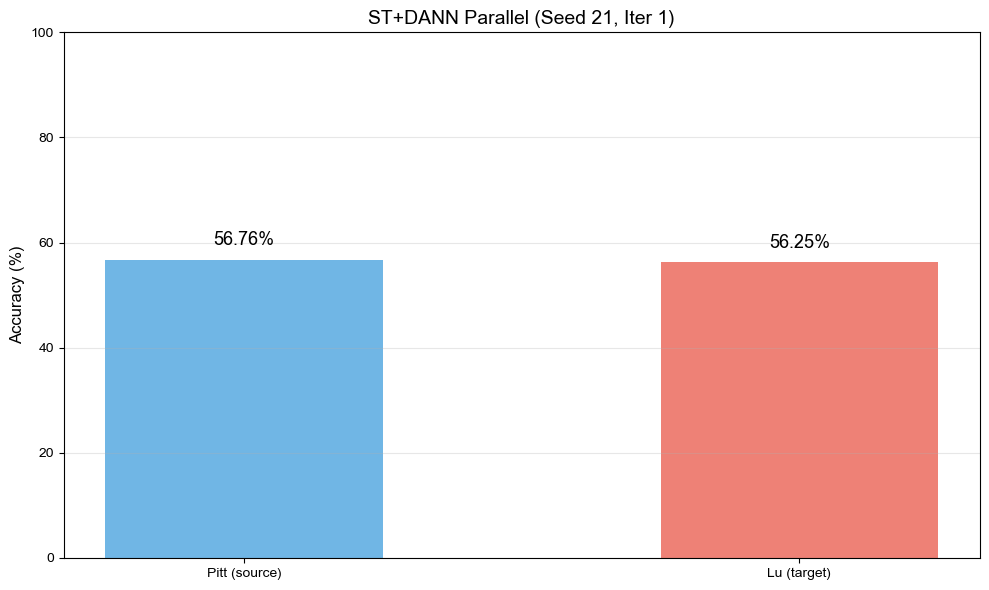

In [8]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_losses'],
    val_loss=best_history['val_losses'],
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 42

In [9]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel_egemaps(
    seed=42,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training on source only (30 epochs)

PHASE 1: DANN Training (Seed 42)


Epoch   1 | Train: 0.541 | Source Val: 0.568 | Target Val: 0.500 | Avg: 0.534 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5338)


Epoch   2 | Train: 0.516 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.573 | Source Val: 0.495 | Target Val: 0.438 | Avg: 0.466 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.559 | Source Val: 0.541 | Target Val: 0.375 | Avg: 0.458 | Domain: 0.000 | λ_dom: 0.000


...

Epoch   8 | Train: 0.592 | Source Val: 0.541 | Target Val: 0.562 | Avg: 0.552


Epoch   9 | Train: 0.590 | Source Val: 0.559 | Target Val: 0.562 | Avg: 0.561


Epoch  10 | Train: 0.588 | Source Val: 0.559 | Target Val: 0.438 | Avg: 0.498


Epoch  11 | Train: 0.561 | Source Val: 0.550 | Target Val: 0.500 | Avg: 0.525
Early stopping at epoch 11
Iteration 1 completed: Avg 56.93% | Source 51.35% | Target 62.50%

ST Iteration 2



Pseudo-label Generation (threshold=0.70):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Only 0 pseudo-samples (< 2), stopping ST

Phase 2 completed. Best iteration: 1, Avg 56.93%


Training Completed (Seed 42)



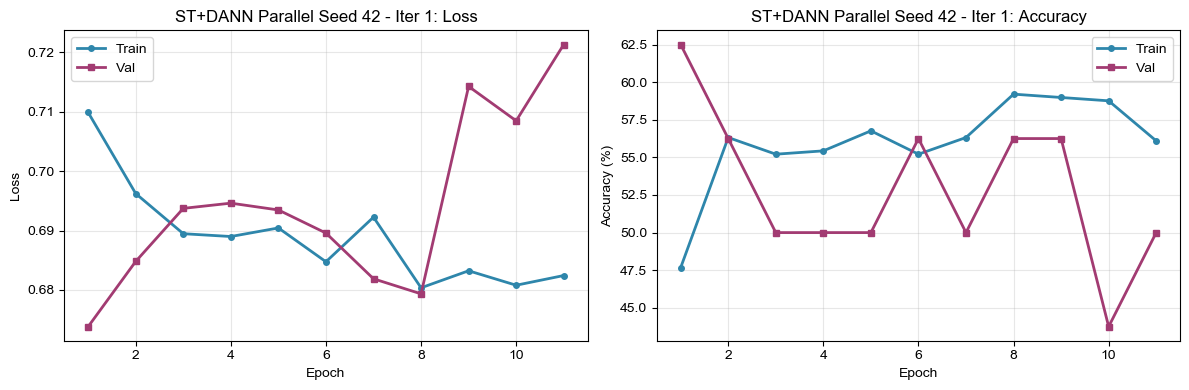

Evaluating Best Model (Seed 42)
Best Iteration: 1
Best Avg Acc: 56.93%
  Source: 51.35%
  Target: 62.50%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_DANN_parallel_Pitt_to_Lu_egemaps_t70/seed_42/st_iter_1.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           51.35%      0.6250       72.58%       24.49%    0.6994
Lu (target domain)             62.50%      0.6250       62.50%       62.50%    0.6738
-------------------------------------------------------------------------------------


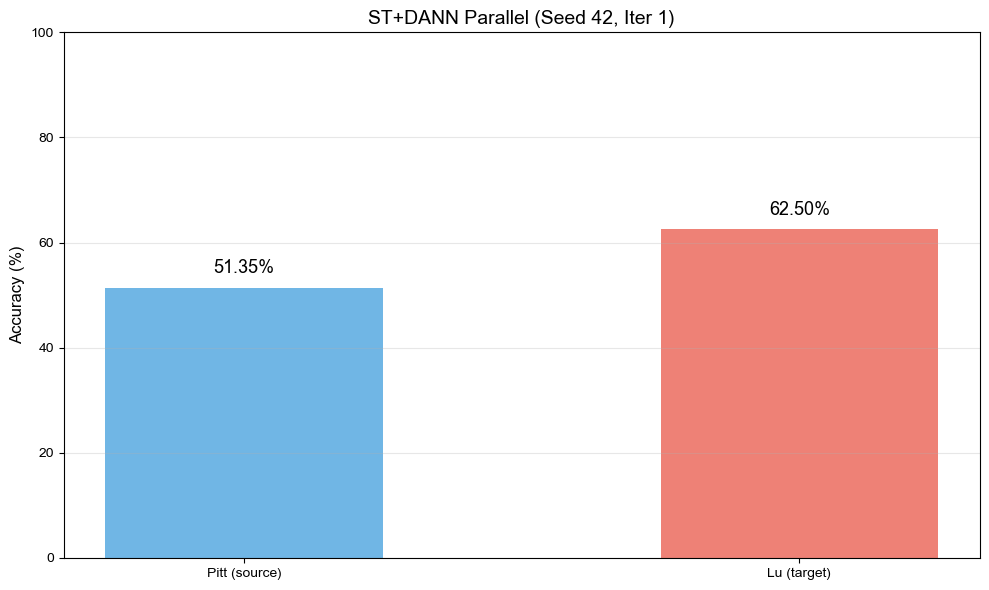

In [10]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_losses'],
    val_loss=best_history['val_losses'],
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 84

In [11]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel_egemaps(
    seed=84,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training on source only (30 epochs)

PHASE 1: DANN Training (Seed 84)


Epoch   1 | Train: 0.514 | Source Val: 0.495 | Target Val: 0.562 | Avg: 0.529 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5290)


Epoch   2 | Train: 0.555 | Source Val: 0.514 | Target Val: 0.500 | Avg: 0.507 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.564 | Source Val: 0.495 | Target Val: 0.438 | Avg: 0.466 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.566 | Source Val: 0.514 | Target Val: 0.375 | Avg: 0.444 | Domain: 0.000 | λ_dom: 0.000


...

Epoch   8 | Train: 0.528 | Source Val: 0.559 | Target Val: 0.438 | Avg: 0.498


Epoch   9 | Train: 0.582 | Source Val: 0.468 | Target Val: 0.312 | Avg: 0.390


Epoch  10 | Train: 0.585 | Source Val: 0.559 | Target Val: 0.375 | Avg: 0.467


Epoch  11 | Train: 0.558 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529
Early stopping at epoch 11
Iteration 5 completed: Avg 54.28% | Source 58.56% | Target 50.00%

ST Iteration 6



Pseudo-label Generation (threshold=0.70):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Only 0 pseudo-samples (< 2), stopping ST

Phase 2 completed. Best iteration: 1, Avg 57.85%


Training Completed (Seed 84)



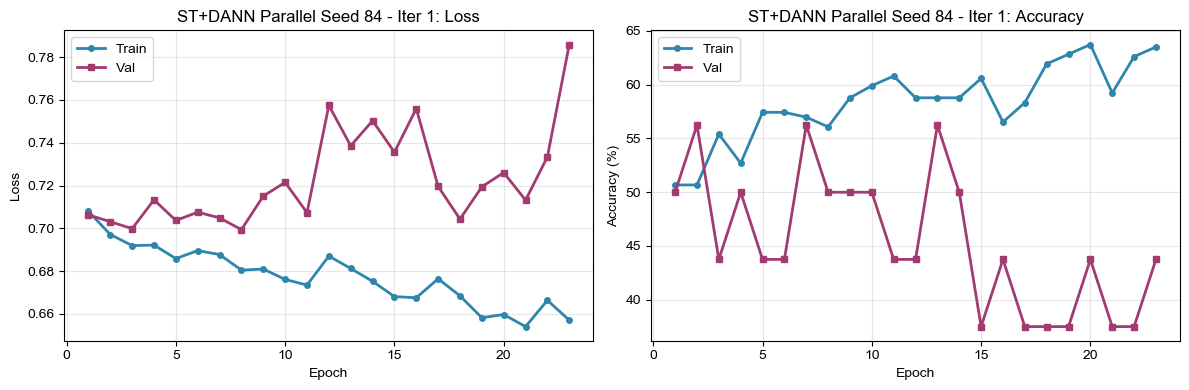

Evaluating Best Model (Seed 84)
Best Iteration: 1
Best Avg Acc: 57.85%
  Source: 59.46%
  Target: 56.25%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_DANN_parallel_Pitt_to_Lu_egemaps_t70/seed_84/st_iter_1.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           59.46%      0.7059       87.10%       24.49%    0.6841
Lu (target domain)             56.25%      0.6667       87.50%       25.00%    0.7386
-------------------------------------------------------------------------------------


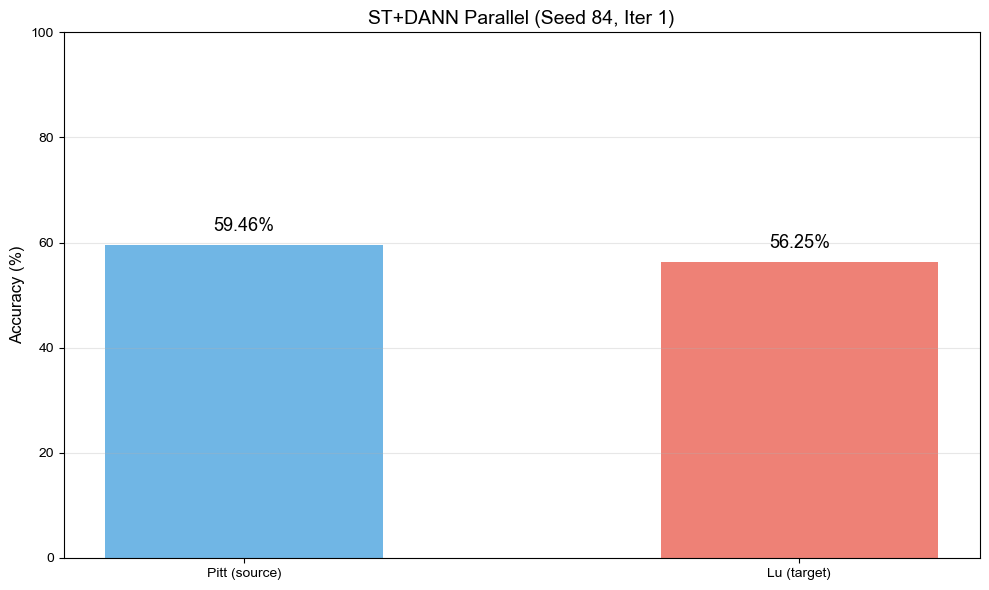

In [12]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_losses'],
    val_loss=best_history['val_losses'],
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 168

In [13]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel_egemaps(
    seed=168,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training on source only (30 epochs)

PHASE 1: DANN Training (Seed 168)


Epoch   1 | Train: 0.491 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5293)


Epoch   2 | Train: 0.566 | Source Val: 0.550 | Target Val: 0.500 | Avg: 0.525 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.559 | Source Val: 0.550 | Target Val: 0.312 | Avg: 0.431 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.570 | Source Val: 0.505 | Target Val: 0.375 | Avg: 0.440 | Domain: 0.000 | λ_dom: 0.000


...

Epoch   9 | Train: 0.562 | Source Val: 0.495 | Target Val: 0.500 | Avg: 0.498


Epoch  10 | Train: 0.580 | Source Val: 0.550 | Target Val: 0.500 | Avg: 0.525


Epoch  11 | Train: 0.591 | Source Val: 0.495 | Target Val: 0.375 | Avg: 0.435


Epoch  12 | Train: 0.580 | Source Val: 0.468 | Target Val: 0.438 | Avg: 0.453
Early stopping at epoch 12
Iteration 1 completed: Avg 53.38% | Source 56.76% | Target 50.00%

ST Iteration 2



Pseudo-label Generation (threshold=0.70):
  Total target samples: 58, Selected: 1 (1.7%)
  Control: 1, Dementia: 0

⚠️  Only 1 pseudo-samples (< 2), stopping ST

Phase 2 completed. Best iteration: 0, Avg 59.18%


Training Completed (Seed 168)



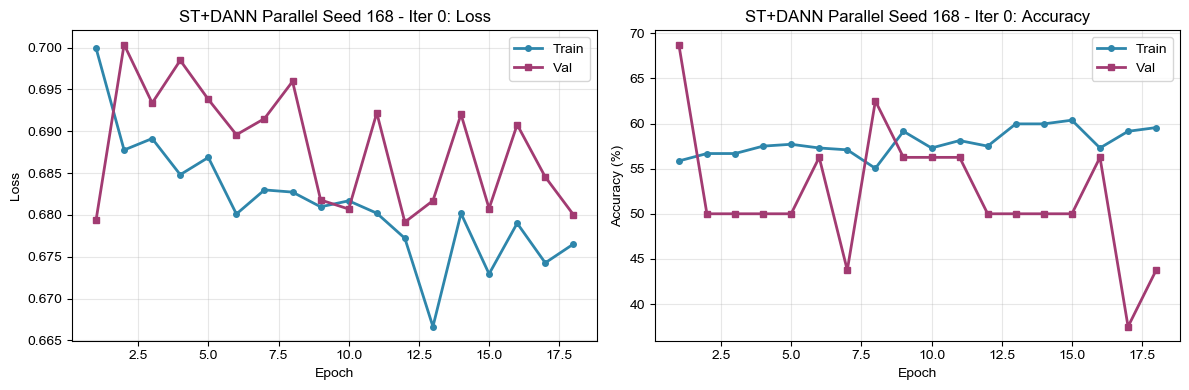

Evaluating Best Model (Seed 168)
Best Iteration: 0
Best Avg Acc: 59.18%
  Source: 55.86%
  Target: 62.50%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_DANN_parallel_Pitt_to_Lu_egemaps_t70/seed_168/st_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           55.86%      0.7066       95.16%        6.12%    0.6894
Lu (target domain)             62.50%      0.7273      100.00%       25.00%    0.6960
-------------------------------------------------------------------------------------


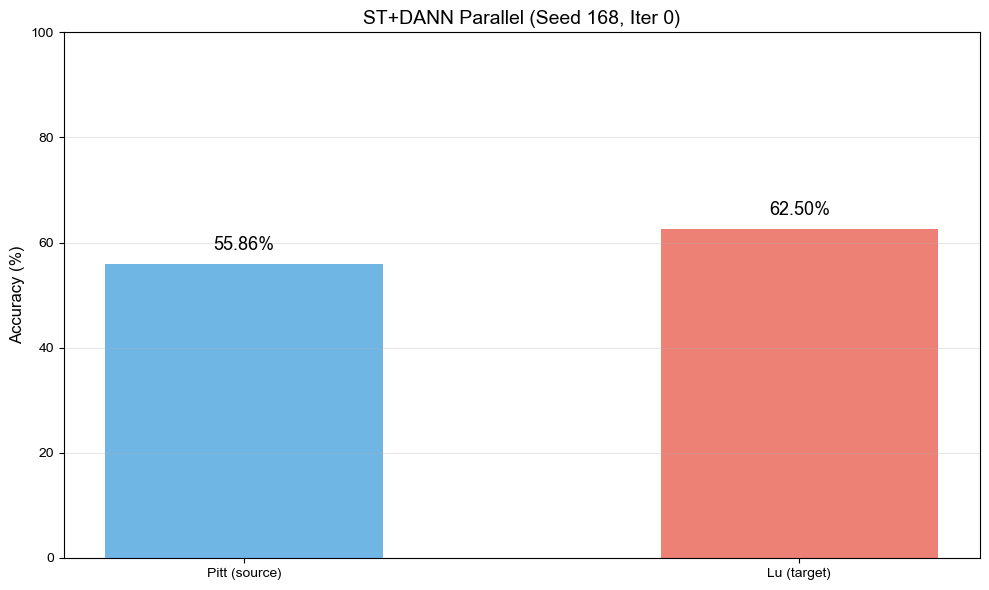

In [14]:

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_losses'],
    val_loss=best_history['val_losses'],
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 336

In [15]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel_egemaps(
    seed=336,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training on source only (30 epochs)

PHASE 1: DANN Training (Seed 336)


Epoch   1 | Train: 0.548 | Source Val: 0.559 | Target Val: 0.562 | Avg: 0.561 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5605)


Epoch   2 | Train: 0.555 | Source Val: 0.586 | Target Val: 0.500 | Avg: 0.543 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.589 | Source Val: 0.514 | Target Val: 0.500 | Avg: 0.507 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.548 | Source Val: 0.559 | Target Val: 0.625 | Avg: 0.592 | Domain: 0.000 | λ_dom: 0.000
  → Primary best model saved (Avg: 0.5918)


...

Epoch  16 | Train: 0.554 | Source Val: 0.559 | Target Val: 0.438 | Avg: 0.498


Epoch  17 | Train: 0.579 | Source Val: 0.595 | Target Val: 0.500 | Avg: 0.547


Epoch  18 | Train: 0.620 | Source Val: 0.495 | Target Val: 0.375 | Avg: 0.435


Epoch  19 | Train: 0.604 | Source Val: 0.541 | Target Val: 0.250 | Avg: 0.395
Early stopping at epoch 19
Iteration 1 completed: Avg 58.31% | Source 60.36% | Target 56.25%

ST Iteration 2



Pseudo-label Generation (threshold=0.70):
  Total target samples: 58, Selected: 1 (1.7%)
  Control: 1, Dementia: 0

⚠️  Only 1 pseudo-samples (< 2), stopping ST

Phase 2 completed. Best iteration: 1, Avg 58.31%


Training Completed (Seed 336)



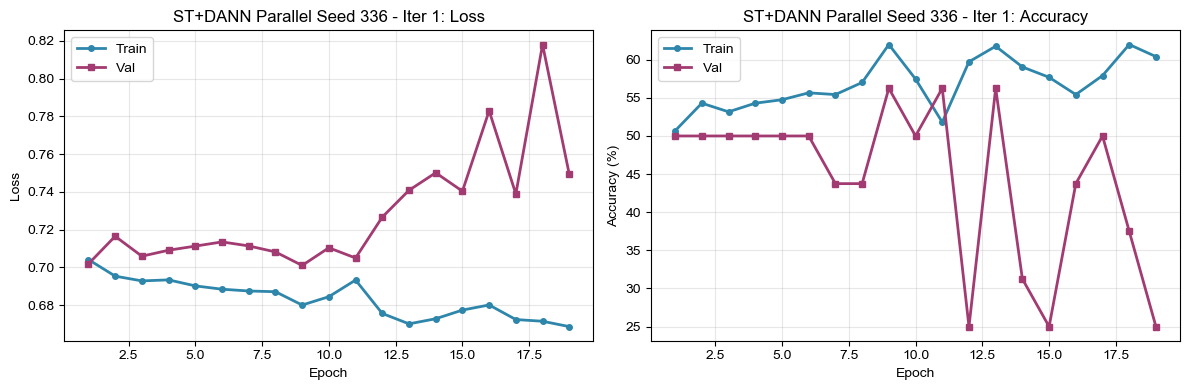

Evaluating Best Model (Seed 336)
Best Iteration: 1
Best Avg Acc: 58.31%
  Source: 60.36%
  Target: 56.25%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_DANN_parallel_Pitt_to_Lu_egemaps_t70/seed_336/st_iter_1.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           60.36%      0.7027       83.87%       30.61%    0.6842
Lu (target domain)             56.25%      0.6316       75.00%       37.50%    0.7010
-------------------------------------------------------------------------------------


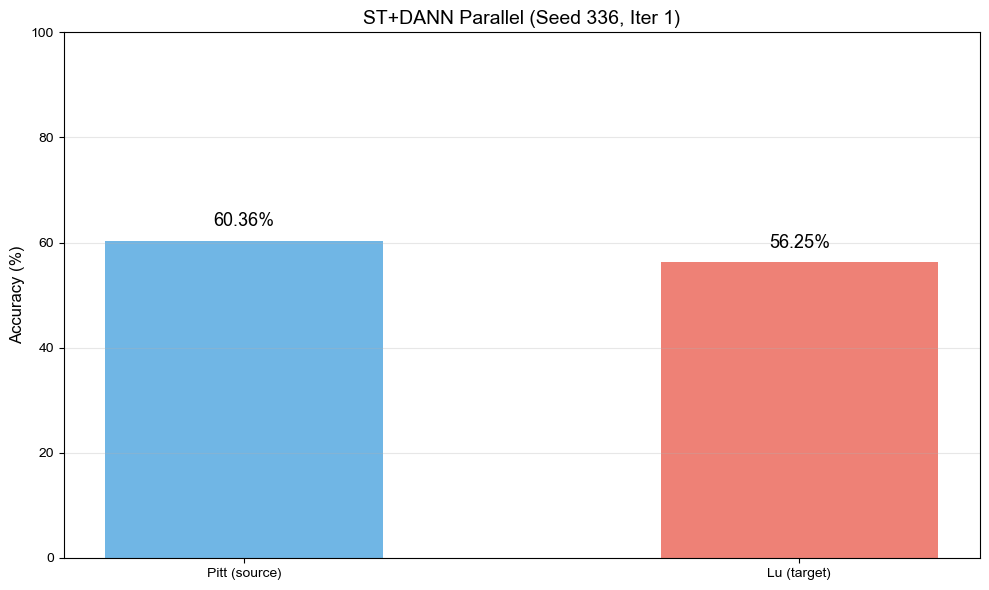

In [16]:

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_losses'],
    val_loss=best_history['val_losses'],
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Summary of Results

In [17]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")

Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
Pitt (source domain)       56.76% ± 3.17%    0.6888 ± 0.0319      0.6881
Lu (target domain)         58.75% ± 3.06%    0.6692 ± 0.0386      0.7019
------------------------------------------------------------------------------------------

Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       Pitt (source domain)           56.76%      0.7037       91.94%       12.24%    0.6834
         Lu (target domain)             56.25%      0.6957      100.00%       12.50%    0.7003
------------------------------------------------------------------------------------------
42       Pitt (source domain)           51.35%      0.6250       72.58%       24.49%    0.6994
         Lu (target do